<h1>รันโปรแกรม splitting ก่อน !!!! <h1>

In [2]:
import os
# must come *before* any Tensorflow import
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [3]:
# !pip install --upgrade --no-cache-dir gdown

In [4]:
# # 1. Upgrade gdown to the latest version
# !pip install --upgrade --no-cache-dir gdown

# # 2. Download using the ID directly (without the --id flag)
# !gdown --folder "1xIX3HLMC7CQLE44tlwiv87TWW2RSyANC"

# # 3. Unzip it
# !unrar x '/content/figshare_braintumor_split.rar' -d ./

In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

In [6]:
# pip install keras-unet-collection

In [7]:
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import tensorflow as tf
import matplotlib.image as mpimg
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score
from sklearn.metrics import classification_report
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.layers import Dense, Flatten, Conv2D, GlobalAveragePooling2D, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.metrics import Recall
from tensorflow.keras.models import Sequential

In [8]:
def set_seed(seed_value=12345):
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)
    os.environ['PYTHONHASHSEED'] = str(seed_value)

set_seed()
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

<h2>Load data into X, y, label<h2>

In [9]:
# def load_split(base_dir, split):
#     images_dir = os.path.join(base_dir, split, 'images')
#     masks_dir  = os.path.join(base_dir, split, 'masks')

#     X, y, labels = [], [], []

#     # Iterate over numbered subfolders (1, 2, 3, ...)
#     for subfolder in sorted(os.listdir(images_dir)):
#         sub_img_dir  = os.path.join(images_dir, subfolder)
#         sub_mask_dir = os.path.join(masks_dir,  subfolder)

#         if not os.path.isdir(sub_img_dir):  # skip non-folders
#             continue

#         for fname in sorted(os.listdir(sub_img_dir)):
#             if not fname.lower().endswith(('.png', '.jpg', '.jpeg', '.tif')):
#                 continue

#             # Parse label: <global_id>_<patient_id>_<label>.ext
#             label = fname.rsplit('.', 1)[0].split('_')[-1]

#             img  = Image.open(os.path.join(sub_img_dir,  fname)).convert('RGB')
#             mask = Image.open(os.path.join(sub_mask_dir, fname)).convert('L')

#             img  = img.resize((224, 224))
#             mask = mask.resize((224, 224))

#             X.append(np.array(img))
#             y.append(np.array(mask))
#             labels.append(label)

#     return np.array(X), np.array(y), labels

<h2>New Load data into X, y, label<h2>

In [10]:
def load_split(base_dir, split):
    images_dir = os.path.join(base_dir, split, 'images')
    X, labels = [], []  # ← removed y (masks)

    for subfolder in sorted(os.listdir(images_dir)):
        sub_img_dir = os.path.join(images_dir, subfolder)

        if not os.path.isdir(sub_img_dir): continue

        for fname in sorted(os.listdir(sub_img_dir)):
            if not fname.lower().endswith(('.png', '.jpg', '.jpeg', '.tif')): continue

            if subfolder == 'no_tumor':
                label = 3
            else:
                label = int(subfolder) - 1  # ← use subfolder name, not filename

            img = Image.open(os.path.join(sub_img_dir, fname)).convert('RGB').resize((224, 224))

            X.append(np.array(img))
            labels.append(label)

    return np.array(X), np.array(labels)  # ← removed y

<h2>TEST SHOW IMAGE + MASK<h2>

File name :  112_108550_1.jpg
Image shape: (512, 512)


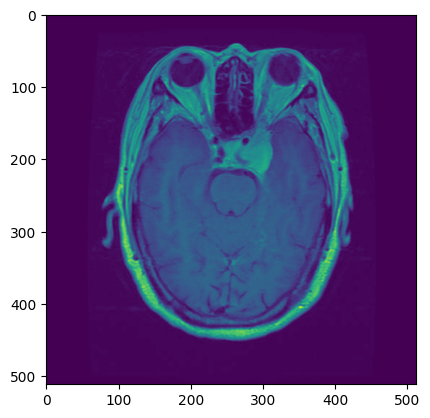

File name :  112_108550_1.jpg
Image shape: (512, 512)


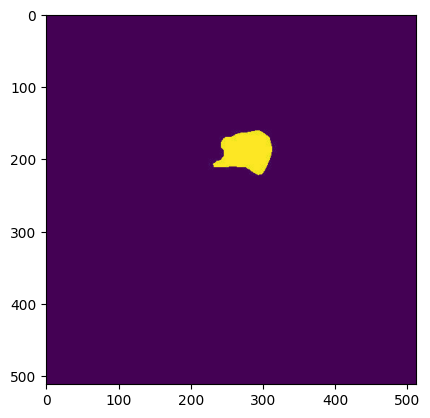

TRAIN FILES
['101_107494_1.jpg', '102_107494_1.jpg', '103_107494_1.jpg', '111_108550_1.jpg', '112_108550_1.jpg', '113_108590_1.jpg', '114_108590_1.jpg', '115_108945_1.jpg', '116_108945_1.jpg']
MASK FILES
['101_107494_1.jpg', '102_107494_1.jpg', '103_107494_1.jpg', '111_108550_1.jpg', '112_108550_1.jpg', '113_108590_1.jpg', '114_108590_1.jpg', '115_108945_1.jpg', '116_108945_1.jpg']


In [11]:
BASE_DIR = '../data/figshare_braintumor_split'
TRAIN_PATH = os.path.join(BASE_DIR, 'train', 'images', '1')
MASK_PATH = os.path.join(BASE_DIR, 'train', 'masks', '1')

train_images_files = os.listdir(TRAIN_PATH)
train_masks_files = os.listdir(MASK_PATH)
train_images_files.sort()
train_masks_files.sort()
image_filename = train_images_files[5]
mask_filename = train_masks_files[5]
image_path = os.path.join(TRAIN_PATH, image_filename)
mask_path = os.path.join(MASK_PATH, mask_filename)

im = mpimg.imread(image_path)
im_mask = mpimg.imread(mask_path)
print("File name : ",image_filename)
print(f"Image shape: {im.shape}")
plt.imshow(im)
plt.show()
print("File name : ",mask_filename)
print(f"Image shape: {im_mask.shape}")
plt.imshow(im_mask)
plt.show()
print("TRAIN FILES")
print(train_images_files[1:10])
print("MASK FILES")
print(train_masks_files[1:10])

<h2>NORMALIZING IMAGES<h2>

In [12]:
X_train, y_train = load_split(BASE_DIR, 'train')
X_val, y_val = load_split(BASE_DIR, 'val')
X_test, y_test = load_split(BASE_DIR, 'test')

# Normalize pixel values to [0, 1]
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3220, 224, 224, 3)
y_train shape: (3220,)
X_val shape: (334, 224, 224, 3)
y_val shape: (334,)
X_test shape: (910, 224, 224, 3)
y_test shape: (910,)


In [13]:
from collections import Counter

print("Class distribution in TRAIN:")
print(Counter(y_train))

print("\nClass distribution in VAL:")
print(Counter(y_val))

print("\nClass distribution in TEST:")
print(Counter(y_test))

Class distribution in TRAIN:
Counter({1: 1019, 3: 1008, 2: 683, 0: 510})

Class distribution in VAL:
Counter({1: 115, 3: 112, 2: 73, 0: 34})

Class distribution in TEST:
Counter({1: 292, 3: 280, 2: 174, 0: 164})


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_train)
y_train_enc = le.transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

print("Classes:", le.classes_)

Classes: [0 1 2 3]


<h1>CLASSIFICATION<h1>

In [15]:
# Load pretrained (ResNet50)
import keras
from keras.applications import ResNet50
resnet50 = ResNet50(weights='imagenet', input_shape=(224,224,3), include_top=False)

In [16]:
# Load pretrained (ResNet50)

import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

In [17]:
# 
resnet50.trainable = True

for layer in resnet50.layers[:140]:
    layer.trainable = False

In [18]:
# Freeze upper layers, add two dense layers and output layer

model_classification = Sequential()
model_classification.add(resnet50)
model_classification.add(GlobalAveragePooling2D())
model_classification.add(Dense(256, activation='relu'))
model_classification.add(Dropout(0.5))
model_classification.add(Dense(256, activation='relu'))
# change dense from 3 to 4
model_classification.add(Dense(4, activation='softmax'))

In [19]:
# One hot encoding
from keras.utils import to_categorical
y_train_ohe = to_categorical(y_train_enc, num_classes=4)
y_val_ohe = to_categorical(y_val_enc, num_classes=4)
y_test_ohe = to_categorical(y_test_enc, num_classes=4)

In [20]:
custom_weights = {0: 4.0, 1: 1.0, 2: 1.5, 3: 0.5}

In [21]:
# Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set up Image generator
#datagen = ImageDataGenerator(
#    rotation_range=20,      # randomly rotate images in the range (degrees, 0 to 180)
#    width_shift_range=0.2,   # randomly shift images horizontally (fraction of total width)
#    height_shift_range=0.2,  # randomly shift images vertically (fraction of total height)
#    horizontal_flip=True, # randomly flip images
#    vertical_flip=False,   # randomly flip images
#)
#
#augmented_data = datagen.flow(X_train, y_train_ohe, seed=12345)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_recall',   
    patience=10,           
    verbose=1,
    mode='max',             
    restore_best_weights=True 
)

In [23]:
model_classification.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy', Recall()]
)

model_classification_history = model_classification.fit(X_train, y_train_ohe, epochs=30, batch_size=16, validation_data=[X_val, y_val_ohe], callbacks=[early_stop])

Epoch 1/30
202/202 [==============================] - 17s 72ms/step - loss: 1.3603 - accuracy: 0.3780 - recall: 0.1112 - val_loss: 1.3290 - val_accuracy: 0.3533 - val_recall: 0.0000e+00
Epoch 2/30
202/202 [==============================] - 13s 64ms/step - loss: 1.0377 - accuracy: 0.5960 - recall: 0.2761 - val_loss: 0.8782 - val_accuracy: 0.7395 - val_recall: 0.3533
Epoch 3/30
202/202 [==============================] - 14s 69ms/step - loss: 0.9025 - accuracy: 0.6637 - recall: 0.4068 - val_loss: 0.7107 - val_accuracy: 0.7934 - val_recall: 0.5539
Epoch 4/30
202/202 [==============================] - 15s 74ms/step - loss: 0.8098 - accuracy: 0.6978 - recall: 0.4988 - val_loss: 0.6295 - val_accuracy: 0.7994 - val_recall: 0.6407
Epoch 5/30
202/202 [==============================] - 13s 63ms/step - loss: 0.7547 - accuracy: 0.7227 - recall: 0.5382 - val_loss: 0.5712 - val_accuracy: 0.8323 - val_recall: 0.7156
Epoch 6/30
202/202 [==============================] - 15s 73ms/step - loss: 0.6816 - a

29/29 [==============================] - 3s 62ms/step
Accuracy score: 0.8274725274725274


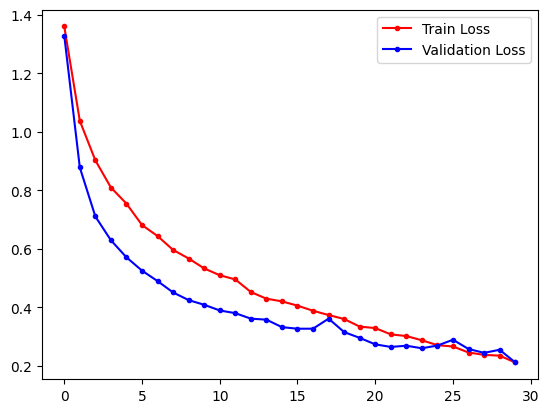

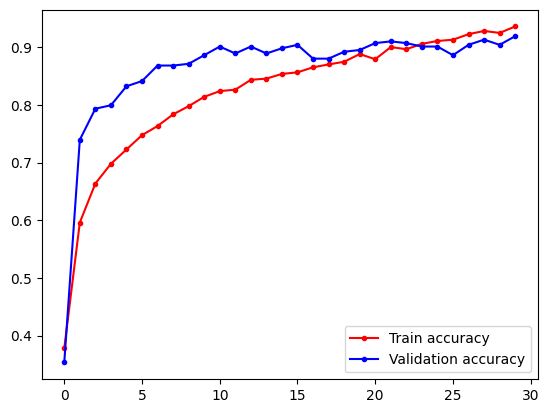

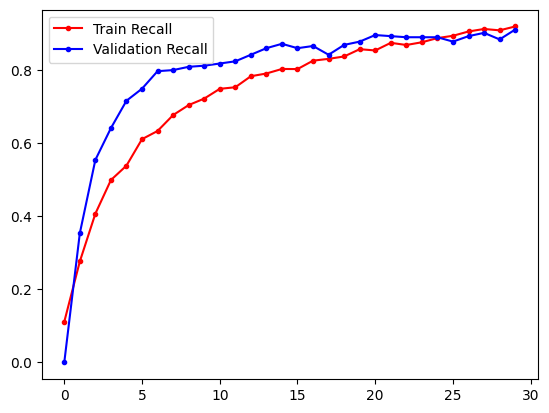

In [24]:
from sklearn.metrics import accuracy_score
y_pred = model_classification.predict(X_test)
accuracy = accuracy_score(y_test, np.argmax(y_pred, axis=1))

print("Accuracy score:", accuracy)

fig, ax= plt.subplots()
ax.plot(model_classification_history.history["loss"], 'r', marker='.', label="Train Loss")
ax.plot(model_classification_history.history["val_loss"], 'b', marker='.', label="Validation Loss")
ax.legend()

fig, bx= plt.subplots()
bx.plot(model_classification_history.history["accuracy"], 'r', marker='.', label="Train accuracy")
bx.plot(model_classification_history.history["val_accuracy"], 'b', marker='.', label="Validation accuracy")
bx.legend()

fig, cx = plt.subplots()
cx.plot(model_classification_history.history["recall"], 'r', marker='.', label="Train Recall")
cx.plot(model_classification_history.history["val_recall"], 'b', marker='.', label="Validation Recall")
cx.legend()
plt.show()

              precision    recall  f1-score   support

     Tumor 1       0.64      0.59      0.62       164
     Tumor 2       0.75      0.79      0.77       292
     Tumor 3       0.87      0.89      0.88       174
    No Tumor       0.98      0.97      0.97       280

    accuracy                           0.83       910
   macro avg       0.81      0.81      0.81       910
weighted avg       0.83      0.83      0.83       910



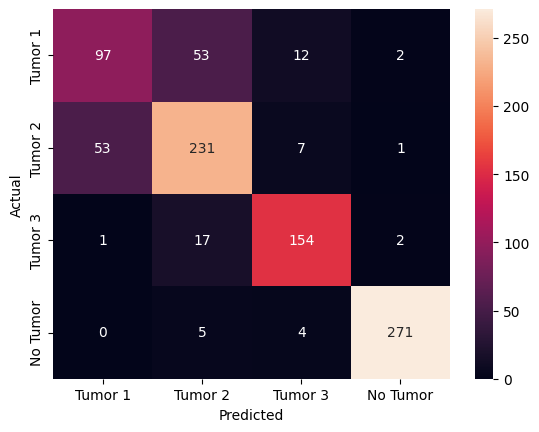

In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

class_names = ['Tumor 1', 'Tumor 2', 'Tumor 3', 'No Tumor']

print(classification_report(y_test, np.argmax(y_pred, axis=1), target_names=class_names))

cm = confusion_matrix(y_test, np.argmax(y_pred, axis=1))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [26]:
model_classification.save_weights('../models/brain_tumor_classification_weights.h5')